
**-----PROJEKT--GRUPP6-----** <br>
Pär Hedström<br>
Fredrik Domert Eriksson<br>
Rickard Andersson<br>

**Data Collection Spider**<br>
Jag har gjort ett försök till att bygga en Spider som utför Web Scraping. Den simulerar en mänsklig användare för att hämta strukturerad data från en databas. Eller i det här fallet en webbsida. Jag har byggt den ganska generellt just med filter-valen, det kan vi ju ändra lite som vi vill sen när vi är överens. Men den fungerar bra. Den laddar ner en csv-fil i en mapp (data_folder) som skapas i den mapp där jupyter-filen ligger. När man kör koden så kommer hemsidan upp och sen tar det kanske 10 sek innan den skriver i sökfältet. /RA

In [1]:
# Använt kod från https://www.geeksforgeeks.org/web-scraping/scrape-linkedin-using-selenium-and-beautiful-soup-in-python/

# Installerar selenium för att kunna hantera knappar och menyer
%pip install selenium

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importerar dom bibliotek vi behöver

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import Select
import time
import os

# --- KONFIGURATION & SÖKVÄGAR ---
SEARCH_TERM = "Avsiktligt självdestruktiv handling"
DATA_DIR = os.path.join(os.getcwd(), "data_folder")

# Skapar en mapp om den inte redan finns
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

chrome_options = Options()
chrome_options.add_experimental_option("prefs", {
    "download.default_directory": DATA_DIR,
    "download.prompt_for_download": False,
    "download.directory_upgrade": True,
    "safebrowsing.enabled": True
})

driver = webdriver.Chrome(options=chrome_options)
wait = WebDriverWait(driver, 20)

# Här startas sidan (socialstyrelsen) där man kan välja filter och använda sökfältet 
try:
    print(f"Startar sökning. Filer kommer sparas i: {DATA_DIR}")
    driver.get("https://sdb.socialstyrelsen.se/if_dor/val.aspx")

    print("Väljer månadsuppgifter...")
    # Det första vi vill göra är att välja månadsuppgifter då det ändrar filtreringen
    try:
        # Vi letar efter select-elementet inuti diven
        select_ar_manad = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "div[id*='armanad_ind'] select"))) # Div-element för År/månadsuppgifter
        s_typer = Select(select_ar_manad)
        s_typer.select_by_visible_text("Månadsuppgifter")
        
        # Trigga sidans eget skript för att rita om gränssnittet till månadsvisning
        driver.execute_script("arguments[0].onchange();", select_ar_manad)
    except Exception as e:
        # Om select-logiken inte fungerar
        print("Kör reservmetod för månadsuppgifter...")
        driver.execute_script("document.querySelector(\"div[id*='armanad_ind'] select\").value = 'm';")
    time.sleep(2.5)

    # Om det ligger gamla val eller text i sökfält så rensas det
    print("Nollställer tidigare val...")
    try:
        rensa = wait.until(EC.element_to_be_clickable((By.ID, "ph1_val_dia_id_btnRensaValda"))) # html-element för rensning av val
        driver.execute_script("arguments[0].click();", rensa)
    except:
        pass

    # Använder sökfältet
    print(f"Söker efter: '{SEARCH_TERM}'...")
    sok_falt = wait.until(EC.element_to_be_clickable((By.ID, "Sokord"))) # html-element för sökfält
    sok_falt.clear()
    sok_falt.send_keys(SEARCH_TERM)
    sok_falt.send_keys(Keys.ENTER)

    # Bockar i rutor för sökresultat
    # Har lagt ut några print då det krånglade en del så jag kunde se vart det tog stopp
    print("Markerar diagnosrutor...")
    wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "#sokListaArea input[type='checkbox']"))) # html-element för checkbox sök-resultat
    checkboxar = driver.find_elements(By.CSS_SELECTOR, "#sokListaArea input[type='checkbox']")
    for cb in checkboxar:
        if not cb.is_selected():
            driver.execute_script("arguments[0].click();", cb)
    
    # Filter för Ålder, Kön och månad där vi bockar i Välj alla
    print("Väljer filter...")
    time.sleep(1)
    knappar_att_klicka = [
        "ph1_val_kon_id_hlAdd",    # Välj alla för Kön
        "ph1_val_ar_id_hlAdd",     # Välj alla för År
        "ph1_val_manad_id_hlAdd"   # Välj alla för Månad
    ]
    
    for knap_id in knappar_att_klicka:
        try:
            knapp = driver.find_element(By.ID, knap_id)
            driver.execute_script("arguments[0].click();", knapp)
            time.sleep(0.1)
        except Exception as e:
            print(f"Kunde inte klicka på filter {knap_id}: {e}")

    # Letar upp knappen för Visa resultat
    # Generera tabell och hämta CSV
    print("Genererar tabell...")
    try:
        # Kör javascript-funktionen direkt
        driver.execute_script("submitResultat();")
    except:
        # Backup om JS-anropet krånglar
        visa_lank = wait.until(EC.element_to_be_clickable((By.ID, "ph1_val_data_id_lnkVisaResultat"))) # html-element
        driver.execute_script("arguments[0].click();", visa_lank)

    # Nu har vi kommit till resultat-sidan av vår sökning.
    # Högst upp till höger letar vi på csv-länken som laddar ner filen till vår mapp.
    print("Hämtar CSV-fil...")
    csv_knapp = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "a[id$='lbCSV']")))
    driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", csv_knapp)
    time.sleep(0.5)
    csv_knapp.click()
    
    print(f"KLART! Din data ligger nu i din mapp.")
    time.sleep(2) # Tid för Chrome då det gick lite för fort tidigare

except Exception as e:
    print(f"Ett fel uppstod: {e}")

# Stänger ner sidan när allt är klart
finally:
    # Vi kollar om driver existerar innan vi försöker stänga den
    if 'driver' in locals() or 'driver' in globals():
        try:
            driver.close() # Stänger fliken
            driver.quit()  # Stänger hela programmet
            print("Webbläsaren stängdes korrekt.")
        except:
            pass # Om den redan var stängd gör vi ingenting

Startar sökning. Filer kommer sparas i: c:\Users\pheds\OneDrive\Desktop\Studier\År 2\Termin 2\DataScience-ML-GIK2KM\Projekt\projekt-grupp6\data_folder
Väljer månadsuppgifter...
Kör reservmetod för månadsuppgifter...
Nollställer tidigare val...
Söker efter: 'Avsiktligt självdestruktiv handling'...
Markerar diagnosrutor...
Väljer filter...
Genererar tabell...
Hämtar CSV-fil...
KLART! Din data ligger nu i din mapp.
Webbläsaren stängdes korrekt.


**Data-Analys**

In [4]:
import pandas as pd

# Hämtar csv filen och spar den i en dataframe. separera med ; och tar bort första raden direkt
data = pd.read_csv('data_folder/Statistikdatabasen_2026-05-27 16_37_26.csv', sep=';', skiprows=1)

# Rensar columnnamn från mellanslag
data['Kön'] = data['Kön'].astype(str).str.strip()

# Tar med endast de rader vi vill ha och rensar ev mellanslag från texten
data['Kön'] = data['Kön'].astype(str).str.strip()
data_clean = data[data['Kön'].isin(['Män', 'Kvinnor', 'Båda könen'])].copy()

# Datan ligger i många kolumner (brett), Vi transformerar till rader istället.
# Enklare för en datorn att hantera 
data_rows = data_clean.melt(
    id_vars=['Kön'], 
    var_name='Månad', 
    value_name='Antal'
)


# Skriver ut och kollar
print(data_rows)



             Kön          Månad  Antal
0            Män   Januari 1997   82.0
1        Kvinnor   Januari 1997   22.0
2     Båda könen   Januari 1997  104.0
3            Män  Februari 1997   70.0
4        Kvinnor  Februari 1997   29.0
...          ...            ...    ...
1045     Kvinnor   Januari 2026     ­­
1046  Båda könen   Januari 2026     ­­
1047         Män  Februari 2026     ­­
1048     Kvinnor  Februari 2026     ­­
1049  Båda könen  Februari 2026     ­­

[1050 rows x 3 columns]


C:\Users\pheds\AppData\Local\Temp\ipykernel_12836\3299915894.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  totals['Antal'] = pd.to_numeric(totals['Antal'], errors='coerce')


Totalsummor för hela perioden (1997-2025):
       Kön    Antal
0  Kvinnor   9915.0
1      Män  23999.0


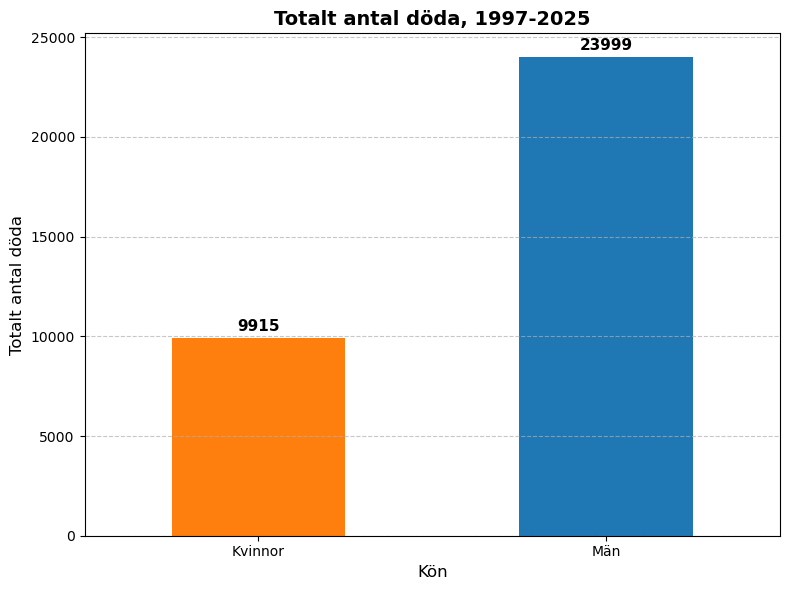

In [5]:
import matplotlib.pyplot as plt

# Kolla hur många män respektive kvinnor i datasetet
# Filtrera bort "Båda könen" så vi bara har 'Män' och 'Kvinnor' kvar.
totals = data_rows[data_rows['Kön'] != 'Båda könen']

# FIXEN: Tvinga 'Antal' att bli siffror. All text blir till tomma värden (NaN) som inte kraschar koden.
totals['Antal'] = pd.to_numeric(totals['Antal'], errors='coerce')

# 2. Gruppera efter 'Kön' och summera kolumnen 'Antal'.
totals = totals.groupby(['Kön'])['Antal'].sum().reset_index()

# Visa resultatet i tabellform (valfritt, men bra för kontroll)
print("Totalsummor för hela perioden (1997-2025):")
print(totals)


# Rita ett stapeldiagram
# sätter 'Kön' på x-axeln och 'Antal' på y-axeln.
ax = totals.plot(
    kind='bar', 
    x='Kön', 
    y='Antal', 
    rot=0,               # Gör så texten 'Män'/'Kvinnor' står rakt, inte snett
    legend=False,         # Vi behöver ingen teckenförklaring här
    figsize=(8, 6),      # Storlek på diagrammet
    color=['#ff7f0e', '#1f77b4'] # Orange för Kvinnor, Blå för Män (färgerna beror på sortering, justera vid behov)    
)

# Snygga till diagrammet med rubriker och rutnät
plt.title('Totalt antal döda, 1997-2025', fontsize=14, fontweight='bold')
plt.ylabel('Totalt antal döda', fontsize=12)
plt.xlabel('Kön', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Visa horisontella stödlinjer

# Lägg till siffror ovanpå staplarna
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()



**Visualisering**